In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, auc
)


In [2]:
train_df = pd.read_csv("churn-bigml-train.csv")
val_df = pd.read_csv("churn-bigml-val.csv")


In [4]:
train_df.head(), train_df.shape, val_df.head(), val_df.shape

(  State  Account length  Area code International plan Voice mail plan  \
 0    KS             128        415                 No             Yes   
 1    OH             107        415                 No             Yes   
 2    NJ             137        415                 No              No   
 3    OH              84        408                Yes              No   
 4    OK              75        415                Yes              No   
 
    Number vmail messages  Total day minutes  Total day calls  \
 0                     25              265.1              110   
 1                     26              161.6              123   
 2                      0              243.4              114   
 3                      0              299.4               71   
 4                      0              166.7              113   
 
    Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
 0             45.07              197.4               99             16.78   
 1    

In [6]:
#Convert Target (Churn)
train_df['Churn'] = train_df['Churn'].astype(int)
val_df['Churn'] = val_df['Churn'].astype(int)

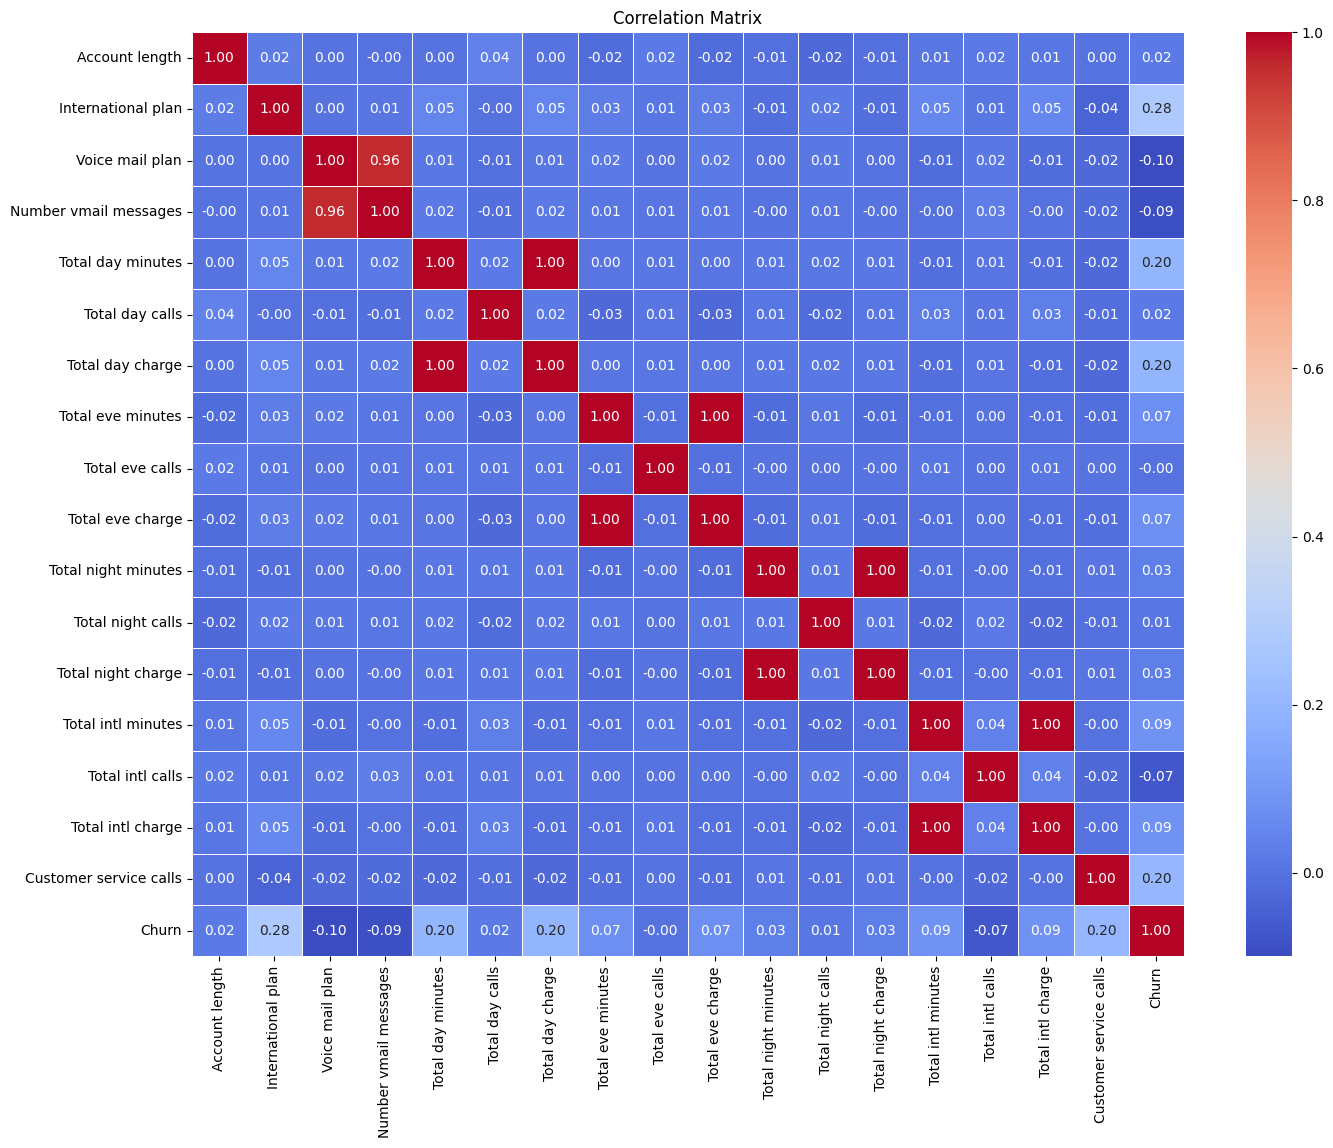

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = train_df.copy()

corr_matrix = corr_df.corr()

plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

In [7]:
# These don’t help prediction
drop_cols = ['State', 'Area code']

train_df = train_df.drop(drop_cols, axis=1)
val_df = val_df.drop(drop_cols, axis=1)

In [8]:
binary_cols = ['International plan', 'Voice mail plan']

for col in binary_cols:
    train_df[col] = train_df[col].map({'Yes': 1, 'No': 0})
    val_df[col] = val_df[col].map({'Yes': 1, 'No': 0})

In [9]:
X_train = train_df.drop('Churn', axis=1)
y_train = train_df['Churn']

X_val = val_df.drop('Churn', axis=1)
y_val = val_df['Churn']

In [10]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

In [13]:
print("\nAccuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Accuracy: 0.8545727136431784
Precision: 0.47368421052631576
Recall: 0.18947368421052632

Confusion Matrix:
[[552  20]
 [ 77  18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       572
           1       0.47      0.19      0.27        95

    accuracy                           0.85       667
   macro avg       0.68      0.58      0.59       667
weighted avg       0.82      0.85      0.83       667



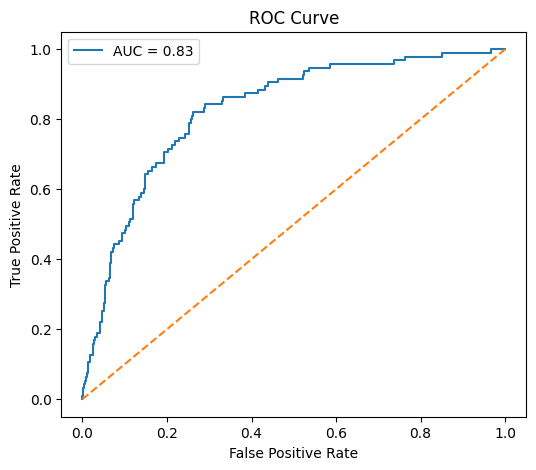

In [14]:
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [15]:
feature_names = train_df.drop('Churn', axis=1).columns
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
})

print("\nTop Influential Features:")
print(coefficients.sort_values(by='Coefficient', ascending=False))


Top Influential Features:
                   Feature  Coefficient
16  Customer service calls     0.661904
1       International plan     0.629652
3    Number vmail messages     0.413974
6         Total day charge     0.340642
4        Total day minutes     0.340551
7        Total eve minutes     0.144036
9         Total eve charge     0.142649
15       Total intl charge     0.142475
13      Total intl minutes     0.136235
12      Total night charge     0.071434
10     Total night minutes     0.071405
5          Total day calls     0.057078
11       Total night calls     0.037849
0           Account length     0.034762
8          Total eve calls    -0.015775
14        Total intl calls    -0.292421
2          Voice mail plan    -0.806578
